# TweetEval sentiment
https://huggingface.co/datasets/cardiffnlp/tweet_eval

In [ ]:
from datasets import load_dataset

ds = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
for i in range(5):
    print(ds["train"][i])

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}
{'text': '"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'label': 1}
{'text': 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.', 'label': 1}
{'text': "Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays", 'label': 1}
{'text': '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"', 'label': 2}


In [ ]:
for i in range(5):
    print(f"Text: {ds['train'][i]['text']}")
    print(f"Label: {ds['train'][i]['label']}")
    print("-" * 50)

Text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: 2
--------------------------------------------------
Text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
Label: 1
--------------------------------------------------
Text: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
Label: 1
--------------------------------------------------
Text: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
Label: 1
--------------------------------------------------
Text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
Label: 2
--------------------------------------------------


# Create a small hand-labeled in-domain validation set from our own election tweets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd

path = "/content/hashtag_donaldtrump.csv"

dt = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="warn"
)

print(dt.shape)
print(dt.columns.tolist())
dt.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/hashtag_donaldtrump.csv'

In [ ]:
n_sample = 300
small_sample = dt.sample(n=min(n_sample, len(dt)), random_state=42).copy()

In [ ]:
# small_sample.to_csv("small_sample.csv", index = False)

# Apply cardiffnlp model
https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment

In [ ]:
!pip -q install transformers scipy scikit-learn

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [ ]:
path = "/content/small_sample_v3.csv"

dt = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="warn"
)

print(dt.shape)
print(dt.columns.tolist())
dt.head(20)

(300, 24)
['created_at', 'tweet_id', 'tweet', 'human_label_context', 'human_label_words_only', 'likes', 'retweet_count', 'source', 'user_id', 'user_name', 'user_screen_name', 'user_description', 'user_join_date', 'user_followers_count', 'user_location', 'lat', 'long', 'city', 'country', 'continent', 'state', 'state_code', 'collected_at', 'Unnamed: 23']


,created_at,tweet_id,tweet,human_label_context,human_label_words_only,likes,retweet_count,source,user_id,user_name,...,user_location,lat,long,city,country,continent,state,state_code,collected_at,Unnamed: 23
0,2020-10-15 3:12:17,1.32E+18,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,0,0.0,Twitter Web App,2.153317e+09,Jim Santo,...,New York City,40.712728,-74.006015,New York,United States of America,North America,New York,NY,2020-10-21 0:17:32,NaN
1,2020-11-06 23:08:49,1.32E+18,#twitter #fakenews #DonaldTrump #JoeBiden #Ele...,1.0,1.0,0,0.0,Twitter Web App,1.060000e+18,The Mob Seat,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-07 11:19:35,NaN
2,2020-10-29 16:00:21,1.32E+18,➡️ Trump propone terminar lotería de #Visas H-...,NaN,NaN,0,0.0,App Political Hispanic,8.960000e+17,Political Hispanic,...,"Washington, DC",38.894992,-77.036558,Washington,United States of America,North America,District of Columbia,DC,2020-10-30 14:45:53,NaN
3,2020-10-16 12:49:59,1.32E+18,#TrumpIsALaughingStock #StableGenius #trump ht...,0.0,2.0,1,0.0,Twitter Web App,1.399251e+08,darren spence,...,Jakarta,-6.175394,106.827183,Jakarta Special Capital Region,Indonesia,Asia,NaN,NaN,2020-10-21 3:17:31,NaN
4,2020-11-05 14:24:25,1.32E+18,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,0,0.0,Twitter for iPhone,4.167809e+07,Adrian Edgar,...,Warwickshire,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-06 9:56:43,NaN
5,2020-11-08 0:12:31,1.33E+18,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,0,0.0,Twitter Web App,7.880000e+17,The Name Is Bond,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-09 17:57:02,NaN
6,2020-11-07 18:24:20,1.33E+18,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,14,1.0,Twitter Web App,7.224311e+08,Juha Keskinen,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-08 10:50:12,NaN
7,2020-11-04 19:21:09,1.32E+18,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,0,0.0,Twitter for Android,1.220000e+18,Christine Stone,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-05 12:03:09,NaN
8,2020-11-02 17:39:53,1.32E+18,@ProjectLincoln #Trump leaves a path of destru...,0.0,0.0,0,0.0,Twitter for iPhone,2.636784e+07,Midevilmack,...,Safely Indoors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-04 10:23:23,NaN
9,2020-10-26 11:15:16,1.32E+18,Trump’s attacks on voting ‘backfired and only ...,0.0,0.0,2,0.0,Twitter Web App,2.395433e+07,Hotpage News,...,United States,39.783730,-100.445882,NaN,United States,North America,NaN,NaN,2020-10-27 17:37:03,NaN


## Preprocess text


### remove short and non-english tweets

In [ ]:
!pip install lingua-language-detector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 4.6 MB/s eta 0:00:00


In [ ]:
from lingua import Language, LanguageDetectorBuilder
detector = LanguageDetectorBuilder.from_all_languages().build()

In [ ]:
def remove_short_and_non_english(text):
    # Return None for very short tweets — lingua is unreliable under ~5 words
    if len(str(text).split()) < 5:
        return None

    detected = detector.detect_language_of(str(text))
    return detected == Language.ENGLISH

In [ ]:
dt['is_english'] = dt['tweet'].apply(remove_short_and_non_english)

In [ ]:
print(dt['is_english'].value_counts(dropna=False))

is_english
True     197
False     91
None      12
Name: count, dtype: int64


In [ ]:
dt_english = dt[dt['is_english'] == True].copy()

### remove urls

In [ ]:
import re

def remove_urls(text):
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '', text).strip()

In [ ]:
dt_english['tweet_clean'] = dt_english['tweet'].apply(remove_urls)

In [ ]:
dt_english = dt_english[dt_english['tweet_clean'].str.strip() != ''].copy()
dt_english = dt_english.reset_index(drop=True)

In [ ]:
dt_english

,created_at,tweet_id,tweet,human_label_context,human_label_words_only,likes,retweet_count,source,user_id,user_name,...,long,city,country,continent,state,state_code,collected_at,Unnamed: 23,is_english,tweet_clean
0,2020-10-15 3:12:17,1.32E+18,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,0,0.0,Twitter Web App,2.153317e+09,Jim Santo,...,-74.006015,New York,United States of America,North America,New York,NY,2020-10-21 0:17:32,NaN,True,"@JoeBiden may not know it yet, but if he troun..."
1,2020-11-05 14:24:25,1.32E+18,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,0,0.0,Twitter for iPhone,4.167809e+07,Adrian Edgar,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-06 9:56:43,NaN,True,@davidhogg111 Do you think #Trump will get the...
2,2020-11-08 0:12:31,1.33E+18,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,0,0.0,Twitter Web App,7.880000e+17,The Name Is Bond,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-09 17:57:02,NaN,True,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...
3,2020-11-07 18:24:20,1.33E+18,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,14,1.0,Twitter Web App,7.224311e+08,Juha Keskinen,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-08 10:50:12,NaN,True,@Jason_elAvocado Yes we are! Even tho #Biden w...
4,2020-11-04 19:21:09,1.32E+18,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,0,0.0,Twitter for Android,1.220000e+18,Christine Stone,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-05 12:03:09,NaN,True,No way that #Trump/Pence2020 did not receive m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2020-11-05 4:14:22,1.32E+18,#Trump #TrumpMeltdown #Lydon Its funny that ...,0.0,0.0,0,0.0,Twitter Web App,3.230300e+09,Michael Merencky,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-06 10:00:38,NaN,True,#Trump #TrumpMeltdown #Lydon Its funny that ...
193,2020-10-26 13:36:20,1.32E+18,@kylegriffin1 Self preservation. He knew that...,0.0,0.0,0,0.0,Twitter Web App,1.075075e+08,Mr. Mark,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-27 17:36:38,NaN,True,@kylegriffin1 Self preservation. He knew that...
194,2020-10-24 4:34:20,1.32E+18,https://t.co/GojNMFh7Q6 \n\n#Trump #ColumbusGa...,1.0,1.0,0,1.0,Twitter Web App,2.293082e+09,Hal S. Pope,...,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-27 17:44:33,NaN,True,#Trump #ColumbusGa #Texas #Maralago #Doral #Tu...
195,2020-10-22 13:52:49,1.32E+18,@gopalbx @SRuhle @GovMurphy @MSNBC #ChrisChris...,0.0,0.0,4,0.0,Twitter for iPhone,1.599926e+07,tortiegertie 🐈🌸🧚‍♀️🌳🍺🥖🧀🍝🍷🍽🍫🐑📷🧶🧳,...,-74.404162,NaN,United States of America,North America,New Jersey,NJ,2020-10-27 17:56:07,NaN,True,@gopalbx @SRuhle @GovMurphy @MSNBC #ChrisChris...


### modeling on dt_english

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
# download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [ ]:
# PreTrain
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.save_pretrained(MODEL)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import torch
def predict_sentiment_dict(text):
  encoded_input = tokenizer(
        text,
        return_tensors="pt"
    )

  with torch.no_grad():
        output = model(**encoded_input)

  scores = output.logits[0].detach().numpy()
  probs = softmax(scores)

  prob_dict = {
        labels[i]: float(probs[i]) for i in range(len(labels))
    }

  return prob_dict

In [ ]:
dt_english["sentiment_probs"] = dt_english["tweet"].apply(predict_sentiment_dict)

In [ ]:
dt_english[["tweet", 'human_label_context', 'human_label_words_only', "sentiment_probs"]].head()

,tweet,human_label_context,human_label_words_only,sentiment_probs
0,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,"{'negative': 0.04322223737835884, 'neutral': 0..."
1,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,"{'negative': 0.24181526899337769, 'neutral': 0..."
2,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,"{'negative': 0.764579176902771, 'neutral': 0.2..."
3,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,"{'negative': 0.46058905124664307, 'neutral': 0..."
4,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,"{'negative': 0.7577735185623169, 'neutral': 0...."


In [ ]:
def get_top_label(prob_dict):
    return max(prob_dict, key=prob_dict.get)

dt_english["sentiment_label"] = dt_english["sentiment_probs"].apply(get_top_label)

In [ ]:
label_to_id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

dt_english["sentiment_label_id"] = dt_english["sentiment_label"].map(label_to_id)

In [ ]:
dt_english[["tweet", 'human_label_context', 'human_label_words_only', "sentiment_probs", 'sentiment_label', 'sentiment_label_id']].head()

,tweet,human_label_context,human_label_words_only,sentiment_probs,sentiment_label,sentiment_label_id
0,"@JoeBiden may not know it yet, but if he troun...",2.0,2.0,"{'negative': 0.04322223737835884, 'neutral': 0...",positive,2
1,@davidhogg111 Do you think #Trump will get the...,0.0,1.0,"{'negative': 0.24181526899337769, 'neutral': 0...",neutral,1
2,@Hafsa_RG @narendramodi @JoeBiden Nothing chan...,0.0,0.0,"{'negative': 0.764579176902771, 'neutral': 0.2...",negative,0
3,@Jason_elAvocado Yes we are! Even tho #Biden w...,0.0,2.0,"{'negative': 0.46058905124664307, 'neutral': 0...",negative,0
4,No way that #Trump/Pence2020 did not receive m...,2.0,2.0,"{'negative': 0.7577735185623169, 'neutral': 0....",negative,0


In [ ]:
# dt_english.to_csv("dt_english_predicted.csv", index = False)

### Confusion matrix

In [ ]:
dt_english['human_label_context'] = dt_english['human_label_context'].astype(int)
dt_english['sentiment_label_id'] = dt_english['sentiment_label_id'].astype(int)

              precision    recall  f1-score   support

    positive       0.45      0.30      0.36        44
     neutral       0.54      0.65      0.59        55
    negative       0.76      0.79      0.77        98

    accuracy                           0.64       197
   macro avg       0.58      0.58      0.57       197
weighted avg       0.63      0.64      0.63       197



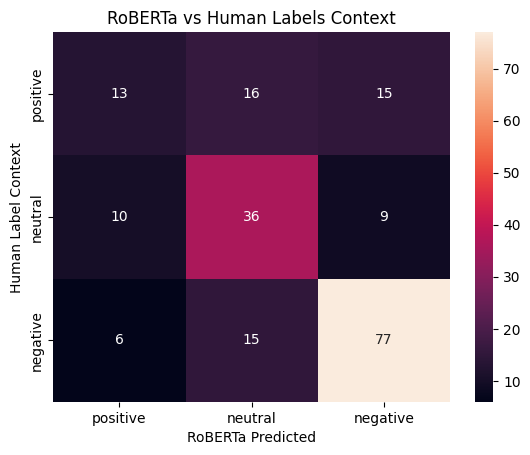

Cohen's kappa: 0.415991649269311


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0],
    target_names=['positive', 'neutral', 'negative']
))

cm = confusion_matrix(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative']
)

plt.xlabel('RoBERTa Predicted')
plt.ylabel('Human Label Context')
plt.title('RoBERTa vs Human Labels Context')
plt.show()

print("Cohen's kappa:", cohen_kappa_score(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id']
))

              precision    recall  f1-score   support

    positive       0.62      0.50      0.55        36
     neutral       0.64      0.66      0.65        65
    negative       0.81      0.85      0.83        96

    accuracy                           0.73       197
   macro avg       0.69      0.67      0.68       197
weighted avg       0.72      0.73      0.72       197



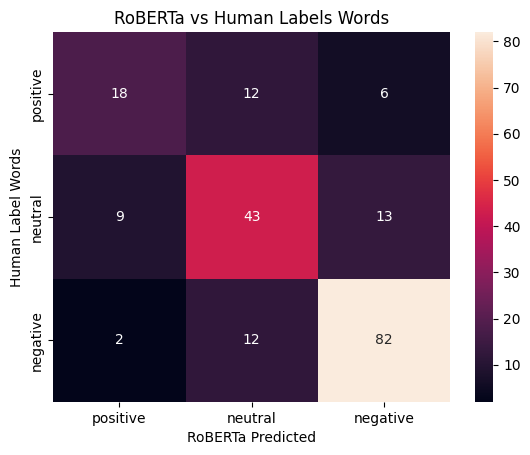

Cohen's kappa: 0.5514042337859493


In [ ]:
print(classification_report(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0],
    target_names=['positive', 'neutral', 'negative']
))

cm = confusion_matrix(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative']
)

plt.xlabel('RoBERTa Predicted')
plt.ylabel('Human Label Words')
plt.title('RoBERTa vs Human Labels Words')
plt.show()

print("Cohen's kappa:", cohen_kappa_score(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id']
))

# Preparing dataset

In [ ]:
import pandas as pd

In [ ]:
biden = pd.read_csv("/content/hashtag_joebiden.csv")

/tmp/ipykernel_1820/2202882825.py:1: DtypeWarning: Columns (1,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  biden = pd.read_csv("/content/hashtag_joebiden.csv")


In [ ]:
biden.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at
0,2020-10-15 00:00:01,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,360666534.0,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,1860.0,"Philadelphia, PA / Miami, FL",25.77427,-80.19366,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00
1,2020-10-15 00:00:18,1.31652929585929e+18,#HunterBiden #HunterBidenEmails #JoeBiden #Joe...,0.0,0.0,Twitter for iPad,809904438.0,Cheri A. 🇺🇸,Biloximeemaw,"Locked and loaded Meemaw. Love God, my family ...",...,6628.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.517827283
2,2020-10-15 00:00:20,1.3165293050069524e+18,@IslandGirlPRV @BradBeauregardJ @MeidasTouch T...,0.0,0.0,Twitter Web App,3494182277.0,Flag Waver,Flag_Wavers,NaN,...,1536.0,Golden Valley Arizona,46.304036,-109.171431,NaN,United States of America,North America,Montana,MT,2020-10-21 00:00:01.035654566
3,2020-10-15 00:00:21,1.3165293080815575e+18,@chrislongview Watching and setting dvr. Let’s...,0.0,0.0,Twitter for iPhone,8.242596012018524e+17,Michelle Ferg,MichelleFerg4,NaN,...,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.553481849
4,2020-10-15 00:00:22,1.316529312741253e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032806955356545e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,390.0,"California, USA",36.701463,-118.755997,NaN,United States of America,North America,California,CA,2020-10-21 00:00:02.071309132


In [ ]:
trump = pd.read_csv("/content/hashtag_donaldtrump.csv", engine="python")

In [ ]:
trump.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at
0,2020-10-15 00:00:01,1.316529221557252e+18,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,TweetDeck,360666534.0,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,...,1860.0,"Philadelphia, PA / Miami, FL",25.77427,-80.19366,NaN,United States of America,North America,Florida,FL,2020-10-21 00:00:00
1,2020-10-15 00:00:01,1.3165292227484303e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.0,Social Mediaset,331617619.0,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,...,1067661.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:00.373216530
2,2020-10-15 00:00:02,1.316529228091847e+18,"#Trump: As a student I used to hear for years,...",2.0,1.0,Twitter Web App,8436472.0,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",...,1185.0,Portland,45.5202471,-122.6741949,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060
3,2020-10-15 00:00:02,1.316529227471237e+18,2 hours since last tweet from #Trump! Maybe he...,0.0,0.0,Trumpytweeter,8.28355589206057e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",...,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-21 00:00:01.119649591
4,2020-10-15 00:00:08,1.3165292523014513e+18,You get a tie! And you get a tie! #Trump ‘s ra...,4.0,3.0,Twitter for iPhone,47413798.0,Rana Abtar - رنا أبتر,Ranaabtar,"Washington Correspondent, Lebanese-American ,c...",...,5393.0,Washington DC,38.8949924,-77.0365581,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121


In [ ]:
merged = pd.concat([biden, trump], ignore_index=True)

# Remove duplicates based on a specific column, keeping the first occurrence
merged = merged.drop_duplicates(subset=["tweet_id"], keep="first")

# reset index after dedup
merged = merged.reset_index(drop=True)

# Save result
merged.to_csv("merged_output.csv", index=False)

In [ ]:
merged = pd.read_csv("merged_output.csv")

/tmp/ipykernel_7316/1866028101.py:1: DtypeWarning: Columns (1,3,6,11) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv("merged_output.csv")


In [ ]:
len(merged)

1553468

In [ ]:
merged["likes"] = pd.to_numeric(merged["likes"], errors='coerce')
merged = merged[(merged["likes"] != 0) & merged["likes"].notna()]

In [ ]:
len(merged)

689819

with na: 689866
without na: 689819

In [ ]:
!pip install lingua-language-detector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.3/170.3 MB 15.1 MB/s eta 0:00:00


In [ ]:
from lingua import Language, LanguageDetectorBuilder
detector = LanguageDetectorBuilder.from_all_languages().build()

In [ ]:
def remove_short_and_non_english(text):
    # Return None for very short tweets — lingua is unreliable under ~5 words
    if len(str(text).split()) < 5:
        return None

    detected = detector.detect_language_of(str(text))
    return detected == Language.ENGLISH

In [ ]:
merged['is_english'] = merged['tweet'].apply(remove_short_and_non_english)

In [ ]:
print(merged['is_english'].value_counts(dropna=False))

is_english
True     396589
False    268528
None      24702
Name: count, dtype: int64


In [ ]:
merged_english = merged[merged['is_english'] == True].copy()

In [ ]:
import re

def remove_urls(text):
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '', text).strip()

In [ ]:
merged_english['tweet_clean'] = merged_english['tweet'].apply(remove_urls)

In [ ]:
merged_english = merged_english[merged_english['tweet_clean'].str.strip() != ''].copy()
merged_english = merged_english.reset_index(drop=True)

In [ ]:
len(merged_english)

396589

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [ ]:
merged_english.to_csv("merged_english.csv", index=False)

In [11]:
merged_english.columns

Index(['created_at', 'tweet_id', 'tweet', 'likes', 'retweet_count', 'source',
       'user_id', 'user_name', 'user_screen_name', 'user_description',
       'user_join_date', 'user_followers_count', 'user_location', 'lat',
       'long', 'city', 'country', 'continent', 'state', 'state_code',
       'collected_at', 'is_english', 'tweet_clean'],
      dtype='object')

In [12]:
print(merged_english["user_followers_count"].dtype)

float64


Calculate engagement score

In [13]:
import numpy as np

In [14]:
merged_english["user_followers_count"] = pd.to_numeric(merged_english["user_followers_count"], errors='coerce')

In [15]:
merged_english['E_raw'] = (merged_english['likes'] + 2 * merged_english['retweet_count']) / (merged_english['user_followers_count'] + 1)
merged_english['E_log'] = np.log1p(merged_english['E_raw'])
log_min = merged_english['E_log'].min()
log_max = merged_english['E_log'].max()
merged_english['E_score'] = (merged_english['E_log'] - log_min) / (log_max - log_min)

In [16]:
merged_english.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,country,continent,state,state_code,collected_at,is_english,tweet_clean,E_raw,E_log,E_score
0,2020-10-15 00:00:22,1.316529e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032807e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,United States of America,North America,California,CA,2020-10-21 00:00:02.071309132,True,#censorship #HunterBiden #Biden #BidenEmails #...,0.002558,0.002554,0.000386
1,2020-10-15 00:00:41,1.316529e+18,Proof Bidens are crooked. Twitter will suspen...,1.0,1.0,Twitter for Android,1.275659e+18,Jake Rivendale,JakeRivendale,NaN,...,NaN,NaN,NaN,NaN,2020-10-21 00:00:04.660445547,True,Proof Bidens are crooked. Twitter will suspen...,0.037037,0.036368,0.005494
2,2020-10-15 00:01:16,1.316530e+18,@tedcruz @cc125 #Trump2020 #BLM #obama #VoteRe...,1.0,0.0,Twitter Web App,1.310040e+18,Infamous One,InfamousOne13,"""The company you keep can have a major impact ...",...,NaN,NaN,NaN,NaN,2020-10-21 00:00:07.249581962,True,@tedcruz @cc125 #Trump2020 #BLM #obama #VoteRe...,0.002770,0.002766,0.000418
3,2020-10-15 00:01:20,1.316530e+18,#IceCube isn’t a sellout how long are black pe...,1.0,1.0,Twitter for iPhone,2.851319e+08,𝓐𝓵𝓮𝔁𝓲𝓪 𝓜𝓪𝓻𝓲𝓮𝓮🧘🏾‍♀️🦋✨,alexiamariee_,snap: 𝒜𝓁𝑒𝓍𝒾𝒶𝓂𝒶𝓇𝒾𝑒𝟤𝟨 ig: 𝒜𝓁𝑒𝓍𝒾𝒶𝓂𝒶𝓇𝒾𝑒𝑒. 🕊🙏🏾Kavou...,...,NaN,NaN,NaN,NaN,2020-10-21 00:00:08.285236528,True,#IceCube isn’t a sellout how long are black pe...,0.005146,0.005133,0.000775
4,2020-10-15 00:01:20,1.316530e+18,BREAKING — Twitter Safety account provides inf...,1.0,1.0,Twitter for iPhone,1.247223e+18,Insider Paper,TheInsiderPaper,Insider Paper is your source to real news from...,...,NaN,NaN,NaN,NaN,2020-10-21 00:00:07.767409245,True,BREAKING — Twitter Safety account provides inf...,0.002498,0.002495,0.000377


Plot to determine threshold (or decide manually)

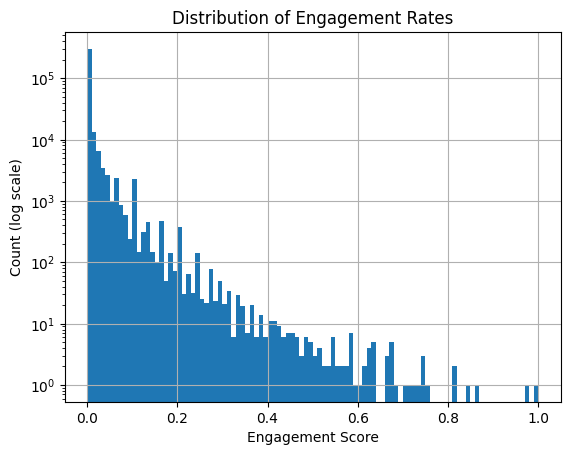

count    335433.000000
mean          0.006285
std           0.024492
min           0.000000
25%           0.000130
33%           0.000206
50%           0.000507
66%           0.001254
75%           0.002306
90%           0.011196
95%           0.028307
99%           0.104716
max           1.000000
Name: E_score, dtype: float64


In [17]:
import matplotlib.pyplot as plt

merged_english['E_score'].hist(bins=100, log=True)
plt.xlabel('Engagement Score')
plt.ylabel('Count (log scale)')
plt.title('Distribution of Engagement Rates')
plt.show()

# Also look at percentiles to understand the distribution
print(merged_english['E_score'].describe(percentiles=[.25, .33, .5, .66, .75, .90, .95, .99]))

In [52]:
merged_english["country"].unique()

array(['United States of America', nan, 'United Kingdom', 'Poland',
       'United States', 'Spain', 'Egypt', 'Jersey', 'Canada', 'Australia',
       'Mongolia', 'Costa Rica', 'Japan', 'South Korea', 'Greece',
       'Turkey', 'Malaysia', 'Georgia', 'New Zealand', 'Slovenia',
       'India', 'The Netherlands', 'Venezuela', 'China',
       'United Arab Emirates', 'Iran', 'Italy', 'France', 'Bangladesh',
       'Finland', 'Cambodia', 'Luxembourg', 'Belgium', 'Germany',
       'Uganda', 'Pakistan', 'Hungary', 'Netherlands', 'Switzerland',
       'Sweden', 'Philippines', 'Singapore', 'Mexico', 'Fiji', 'Austria',
       'Norway', 'Bahrain', 'Ireland', 'Israel', 'Chile', 'Estonia',
       'South Africa', 'Liberia', 'Vietnam', 'Armenia', 'Latvia',
       'Tunisia', 'Serbia', 'Colombia', 'Azerbaijan', 'Qatar', 'Taiwan',
       'Denmark', 'Ethiopia', 'Peru', 'Cuba', 'Russia', 'Lebanon',
       'Indonesia', 'Barbados', 'Argentina', 'Panama', 'Saudi Arabia',
       'Kenya', 'Iceland', 'Tanzania',

In [53]:
((merged_english["country"] == "United States") | (merged_english["country"] == "United States of America")).sum()

np.int64(107530)

In [58]:
merged_english["created_at"][83855]

'2020-11-02 17:17:17'

In [64]:
df = merged_english[((merged_english["country"] == "United States") | (merged_english["country"] == "United States of America")) & (merged_english["state"].notna())]

In [65]:
len(df)

92216

In [71]:
print(df['state'].value_counts())

state
California                  15952
New York                    12694
Texas                        8308
Florida                      7540
District of Columbia         5002
Illinois                     3603
Pennsylvania                 3512
New Jersey                   2492
Massachusetts                2305
Ohio                         1972
Oregon                       1809
North Carolina               1749
Michigan                     1722
Arizona                      1681
Georgia                      1656
Colorado                     1603
Virginia                     1412
Nevada                       1398
Washington                   1266
Maryland                     1172
Tennessee                    1121
Minnesota                    1025
Missouri                      922
Wisconsin                     828
Kentucky                      773
South Carolina                699
Indiana                       677
Louisiana                     666
Kansas                        573
Alabama 

Remove Guam and Northern Mariana Islands due to the very small counts (1 and 2 respectively)

In [77]:
df = df[(df['state'] != "Guam") & (df['state'] != "Northern Mariana Islands")]
print(df['state'].value_counts())

state
California              15952
New York                12694
Texas                    8308
Florida                  7540
District of Columbia     5002
Illinois                 3603
Pennsylvania             3512
New Jersey               2492
Massachusetts            2305
Ohio                     1972
Oregon                   1809
North Carolina           1749
Michigan                 1722
Arizona                  1681
Georgia                  1656
Colorado                 1603
Virginia                 1412
Nevada                   1398
Washington               1266
Maryland                 1172
Tennessee                1121
Minnesota                1025
Missouri                  922
Wisconsin                 828
Kentucky                  773
South Carolina            699
Indiana                   677
Louisiana                 666
Kansas                    573
Alabama                   513
Connecticut               510
Oklahoma                  485
Iowa                      458
Hawa

Final dataset:
- English only
- In the US
- State not NA

# Sentiment analysis

Run df through TwitterRobertaBaseSentiment to get the sentiment classifications of the tweets

In [85]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [86]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [87]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [88]:
# download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [89]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL).to(device)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [90]:
from torch.utils.data import DataLoader

tweets = df["tweet"].astype(str).tolist()

# Tokenize everything at once (returns tensors)
# padding=True and truncation=True make sure all tensors are the same shape
inputs = tokenizer(tweets, padding=True, truncation=True, return_tensors="pt", max_length=128)

# Create a DataLoader to feed the GPU in chunks
dataset = torch.utils.data.TensorDataset(inputs['input_ids'], inputs['attention_mask'])
loader = DataLoader(dataset, batch_size=32)

# Predict in a loop
model.eval()
model.to(device)
all_logits = []

with torch.no_grad():
    for batch in loader:
        b_input_ids, b_attn_mask = [t.to(device) for t in batch]
        outputs = model(input_ids=b_input_ids, attention_mask=b_attn_mask)
        all_logits.append(outputs.logits.cpu())

# Concatenate results and get labels
final_logits = torch.cat(all_logits, dim=0)
probs = torch.nn.functional.softmax(final_logits, dim=-1)

# Convert the probabilities tensor to a NumPy array
probs_np = probs.numpy()

# Add the raw probabilities to dataframe
df["sentiment_probs"] = probs_np.tolist()

# map to labels (labels obtained from the model itself)
indices = np.argmax(probs_np, axis=1)
df["sentiment_label"] = [labels[i] for i in indices]

In [91]:
df.head()

,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,...,state,state_code,collected_at,is_english,tweet_clean,E_raw,E_log,E_score,sentiment_probs,sentiment_label
0,2020-10-15 00:00:22,1.316529e+18,#censorship #HunterBiden #Biden #BidenEmails #...,1.0,0.0,Twitter Web App,1.032807e+18,the Gold State,theegoldstate,A Silicon Valley #independent #News #Media #St...,...,California,CA,2020-10-21 00:00:02.071309132,True,#censorship #HunterBiden #Biden #BidenEmails #...,0.002558,0.002554,0.000386,"[0.6924492120742798, 0.2935495674610138, 0.014...",negative
5,2020-10-15 00:01:42,1.316530e+18,In an effort to find the truth about allegatio...,1.0,0.0,Twitter Web App,1.165118e+18,The Big Homie,_dbrown_23,#YAHDOG Posse's Top Guy.\n@illinivideo\n@Illin...,...,Illinois,IL,2020-10-21 00:00:10.874372943,True,In an effort to find the truth about allegatio...,0.001047,0.001047,0.000158,"[0.4220110774040222, 0.5309473276138306, 0.047...",neutral
6,2020-10-15 00:01:47,1.316530e+18,Twitter is doing everything they can to help D...,1.0,0.0,Twitter for iPhone,1.139962e+18,Wynward,Joelwhct,NaN,...,California,CA,2020-10-21 00:00:11.392200226,True,Twitter is doing everything they can to help D...,0.333333,0.287682,0.043461,"[0.3415294289588928, 0.4945909082889557, 0.163...",neutral
10,2020-10-15 00:02:35,1.316530e+18,A simple question. Who are you voting for? #20...,1.0,1.0,Twitter for Android,8.957270e+17,John MacDonald for the People,jmac4thepeople,"Father, veteran, veteran's advocate, former ca...",...,Massachusetts,MA,2020-10-21 00:00:19.159609471,True,A simple question. Who are you voting for? #20...,0.002392,0.002389,0.000361,"[0.055623218417167664, 0.8585494160652161, 0.0...",neutral
11,2020-10-15 00:02:50,1.316530e+18,Has this awoken you from your slumbers yet @BB...,1.0,0.0,Twitter for iPhone,5.667098e+07,malcolm cowing,MalcolmCowing,Retired former Managing Partner of marcoms age...,...,Virginia,VA,2020-10-21 00:00:21.748745887,True,Has this awoken you from your slumbers yet @BB...,0.000741,0.000740,0.000112,"[0.7433387041091919, 0.23445509374141693, 0.02...",negative


# Baseline models for comparison

Baseline model 1:
- Input: user_id

In [ ]:
merged_english = pd.read_csv('/content/merged_english.csv')

In [ ]:
len(merged_english)

396589

In [ ]:
merged_english = merged_english.dropna(subset=['user_followers_count']).copy()

In [ ]:
len(merged_english)

396514

In [ ]:
merged_english['log_followers_count'] = np.log1p(merged_english['user_followers_count'])

In [ ]:
y = merged_english['E_score']
X = merged_english[['log_followers_count']]

In [ ]:
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

In [ ]:
df_train = merged_english.loc[X_train.index]
df_val = merged_english.loc[X_val.index]

In [ ]:
# Compute mean engagement per user from training set only
user_mean_map = df_train.groupby('user_id')['E_score'].mean()
global_mean = y_train.mean()

# Map mean engagement onto each split
df_train['user_mean_engagement'] = df_train['user_id'].map(user_mean_map)
df_val['user_mean_engagement'] = df_val['user_id'].map(user_mean_map).fillna(global_mean)

# Train baseline
X_train_user = df_train[['user_mean_engagement']]
X_val_user = df_val[['user_mean_engagement']]

baseline_user = LinearRegression()
baseline_user.fit(X_train_user, y_train)

preds_user = baseline_user.predict(X_val_user)

print("User ID baseline:")
print(f"R²:   {r2_score(y_val, preds_user):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, preds_user):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, preds_user)):.4f}")

# Check how many unseen users got the global mean fallback
unseen = ~df_val['user_id'].isin(user_mean_map.index)
print(f"\nUnseen users in val: {unseen.sum()} ({unseen.mean():.1%})")

User ID baseline:
R²:   0.1866
MAE:  0.0376
RMSE: 0.1460

Unseen users in val: 20328 (32.0%)


32% of validation users were unseen in training and received global mean predictions, which likely underestimates the true predictive power of user identity

Baseline model 2:
- Input: follower count

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Single feature — reshape needed for sklearn
X_train_followers = X_train[['log_followers_count']]
X_val_followers = X_val[['log_followers_count']]

baseline_followers = LinearRegression()
baseline_followers.fit(X_train_followers, y_train)

preds = baseline_followers.predict(X_val_followers)

print("Follower count baseline:")
print(f"R²:   {r2_score(y_val, preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, preds)):.4f}")

Follower count baseline:
R²:   0.1934
MAE:  0.0636
RMSE: 0.1454


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained('Twitter/twhin-bert-base')
model = AutoModel.from_pretrained('Twitter/twhin-bert-base')
model.eval()

def get_embedding(texts, batch_size=64):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(
            batch,
            return_tensors='pt',
            truncation=True,
            max_length=128,
            padding=True
        )
        with torch.no_grad():
            outputs = model(**inputs)
        # CLS token as tweet representation
        embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(embeddings.numpy())
    return np.vstack(all_embeddings)

embeddings = get_embedding(merged_english['tweet_clean'].tolist())
np.save('twhin_embeddings.npy', embeddings)